# Mobile price prediction - Linear Regression
 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

## Context:
GSMArena Phones Dataset is a labeled dataset extracted from GSMArena, one of the most popular online provider of phone information, and holds a large collection of phone specification.

### Data Set - 

Domain: Telecom

Data: https://www.kaggle.com/arwinneil/gsmarena-phone-dataset

#### Features

1. brand
2. model
3. network_technology
4. 2G_bands
5. 3G_bands
6. 4G_bands
7. network_speed
8. GPRS
9. EDGE
10. announced
11. status
12. dimentions
13. weight_g
14. weight_oz
15. SIM
16. display_type
17. display_resolution
18. display_size
19. OS
20. CPU
21. Chipset
22. GPU
23. memory_card
24. internal_memory
25. RAM
26. primary_camera
27. secondary_camera
28. loud_speaker
29. audio_jack
30. WLAN
31. bluetooth
32. GPS
33. NFC
34. radio
35. USB
36. sensors
37. battery
38. colors
39. approx_price_EUR
40. img_url

 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

### Objective - 

To predict mobile phone price belonging to a specific brand depending on the available features


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

### Steps to perform:

#### 1. Import Libraries
#### 2. Import Data set and exploration
#### 3. Data Cleansing
#### 4. Data Preparation
#### 5. Data Validation
#### 6. EDA
#### 7. Data Split - Train : Test
#### 8. Supervised Learning modeling: Linear Regression
#### 9. Model Testing: Linear Regression
#### 10. Future data prediction

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


### 1. Import Libraries

In [1]:
import numpy as np   

from sklearn.linear_model import LinearRegression

import pandas as pd    

import matplotlib.pyplot as plt 
%matplotlib inline 

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


### 2. Reading Dataset and Exploration ( report shape of the dataset)

In [2]:
df = pd.read_csv("mobile_price.csv")  

In [3]:
df.shape

(8628, 40)

In [4]:
## There are 8628 rows and 40 columns in the dataset

#### Check a few sample of the dataframe and get familiar with the data

In [5]:
df.head(10)

,brand,model,network_technology,2G_bands,3G_bands,4G_bands,network_speed,GPRS,EDGE,announced,...,bluetooth,GPS,NFC,radio,USB,sensors,battery,colors,approx_price_EUR,img_url
0,Acer,Iconia Talk S,GSM / HSPA / LTE,GSM 850 / 900 / 1800 / 1900 - SIM 1 & SIM 2,HSDPA 850 / 1900 / 2100,LTE band 1(2100)/ 3(1800)/ 7(2600)/ 8(900)/ 20...,HSPA 42.2/11.5 Mbps LTE Cat4 150/50 Mbps,Yes,Yes,2016 August,...,4.0/ A2DP,Yes with A-GPS GLONASS,NaN,FM radio,microUSB 2.0,Accelerometer/ proximity,Non-removable Li-Ion 3400 mAh battery (12.92 Wh),Black,170,http://cdn2.gsmarena.com/vv/bigpic/acer-iconia...
1,Acer,Liquid Z6 Plus,GSM / HSPA / LTE,GSM 850 / 900 / 1800 / 1900 - SIM 1 & SIM 2 (d...,HSDPA,LTE,HSPA 42.2/5.76 Mbps LTE Cat4 150/50 Mbps,Yes,Yes,2016 August,...,4.0/ A2DP,Yes with A-GPS,NaN,FM radio,microUSB 2.0,Fingerprint (front-mounted)/ accelerometer/ pr...,Removable Li-Po 4080 mAh battery,Black/ White,250,http://cdn2.gsmarena.com/vv/bigpic/acer-liquid...
2,Acer,Liquid Z6,GSM / HSPA / LTE,GSM 850 / 900 / 1800 / 1900 - SIM 1 & SIM 2 (d...,HSDPA,LTE,HSPA LTE,Yes,Yes,2016 August,...,Yes,Yes with A-GPS,NaN,FM radio,microUSB 2.0,Accelerometer/ proximity,Removable Li-Ion 2000 mAh battery,Black/ White,120,http://cdn2.gsmarena.com/vv/bigpic/acer-liquid...
3,Acer,Iconia Tab 10 A3-A40,No cellular connectivity,NA,NaN,NaN,NaN,No,No,2016 April,...,Yes,NaN,NaN,No,microUSB 2.0,Accelerometer,Non-removable Li-Ion battery,Black,230,http://cdn2.gsmarena.com/vv/bigpic/acer-iconia...
4,Acer,Liquid X2,GSM / HSPA / LTE,GSM 850 / 900 / 1800 / 1900,HSDPA 900 / 1900 / 2100 - Europe/ Taiwan,LTE 800 / 1800 / 2100 / 2600 - Europe,HSPA 42.2/5.76 Mbps LTE Cat4 150/50 Mbps,Yes,Yes,2015 April,...,4.0/ A2DP/ LE,Yes with A-GPS,NaN,FM radio,microUSB 2.0,Accelerometer/ proximity/ compass,Removable Li-Po 4020 mAh battery,Black/ Gold,230,http://cdn2.gsmarena.com/vv/bigpic/acer-liquid...
5,Acer,Liquid Jade 2,GSM / HSPA / LTE,GSM 850 / 900 / 1800 / 1900 - SIM 1 & SIM 2,HSDPA 900 / 2100,LTE,HSPA 42.2/5.76 Mbps LTE Cat4 150/50 Mbps,Yes,Yes,2016 February,...,4.0/ A2DP/ LE,Yes with A-GPS,NaN,FM radio,microUSB 2.0,Accelerometer/ gyro/ proximity/ compass,NaN,Black,NaN,http://cdn2.gsmarena.com/vv/bigpic/acer-liquid...
6,Acer,Liquid Zest Plus,GSM / HSPA / LTE,GSM 850 / 900 / 1800 / 1900 - SIM 1 & SIM 2 (d...,HSDPA,LTE,HSPA LTE,Yes,Yes,2016 April,...,Yes,Yes with A-GPS,NaN,FM radio,microUSB 2.0,Accelerometer/ proximity/ compass,Non-removable Li-Ion 5000 mAh battery,Blue/ White,200,http://cdn2.gsmarena.com/vv/bigpic/acer-liquid...
7,Acer,Liquid Zest,GSM / HSPA / LTE,GSM 850 / 900 / 1800 / 1900 - SIM 1 & SIM 2 (d...,HSDPA 850 / 900 / 1900 / 2100,LTE,HSPA LTE Cat4 150/50 Mbps,Yes,Yes,2016 February,...,4.0/ A2DP,Yes with A-GPS,NaN,FM radio,microUSB 2.0,Accelerometer/ proximity/ compass,Removable Li-Ion 2000 mAh battery,Black/ White,110,http://cdn2.gsmarena.com/vv/bigpic/acer-zest.jpg
8,Acer,Predator 8,No cellular connectivity,NA,NaN,NaN,NaN,No,No,2015 September,...,4.0/ A2DP/ LE,NaN,NaN,No,microUSB 2.0,Yes,Non-removable Li-Po 4420 mAh battery,Black/Silver,350,http://cdn2.gsmarena.com/vv/bigpic/acer-predat...
9,Acer,Liquid Jade Primo,GSM / HSPA / LTE,GSM 850 / 900 / 1800 / 1900 - SIM 1 & SIM 2,HSDPA 850 / 900 / 1900 / 2100 - Europe/ Taiwan,LTE 800 / 1800 / 2100 / 2600 - Europe,HSPA 42.2/5.76 Mbps LTE-A (2CA) Cat6 300/50 Mbps,Yes,Yes,2015 September,...,4.0/ A2DP/ LE/ EDR,Yes with A-GPS,NaN,FM radio,3.1/ Type-C 1.0 reversible connector,Accelerometer/ gyro/ proximity/ compass,Non-removable Li-Po 2870 mAh battery,Black,220,http://cdn2.gsmarena.com/vv/bigpic/acer-liquid...


#### Check info of the dataframe and comment on datatype of various features

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8628 entries, 0 to 8627
Data columns (total 40 columns):
brand                 8628 non-null object
model                 8628 non-null object
network_technology    8628 non-null object
2G_bands              8628 non-null object
3G_bands              4857 non-null object
4G_bands              1604 non-null object
network_speed         4884 non-null object
GPRS                  8596 non-null object
EDGE                  8605 non-null object
announced             8613 non-null object
status                8628 non-null object
dimentions            8609 non-null object
weight_g              7680 non-null object
weight_oz             7680 non-null object
SIM                   8626 non-null object
display_type          8624 non-null object
display_resolution    7414 non-null object
display_size          8581 non-null object
OS                    4905 non-null object
CPU                   4835 non-null object
Chipset               3691 non-nu

In [7]:
# Here we can see that all the columns belong to object data type.
# approx_price_EUR is the price of the mobile. It should have been int or float datatype. There might be some erroneous entries in this column

#### Check statistical summary of the dataset and comment on your findings

In [8]:
df.iloc[:,0:10].describe().transpose()

,count,unique,top,freq
brand,8628,108,Samsung,1103
model,8628,8274,X500,5
network_technology,8628,38,GSM,3505
2G_bands,8628,209,GSM 850 / 900 / 1800 / 1900,2255
3G_bands,4857,579,HSDPA 900 / 2100,1115
4G_bands,1604,650,LTE,173
network_speed,4884,195,HSPA 21.1/5.76 Mbps,751
GPRS,8596,53,Yes,3547
EDGE,8605,51,Yes,3242
announced,8613,711,2005 1Q,151


In [9]:
df.isnull().sum()

brand                    0
model                    0
network_technology       0
2G_bands                 0
3G_bands              3771
4G_bands              7024
network_speed         3744
GPRS                    32
EDGE                    23
announced               15
status                   0
dimentions              19
weight_g               948
weight_oz              948
SIM                      2
display_type             4
display_resolution    1214
display_size            47
OS                    3723
CPU                   3793
Chipset               4937
GPU                   5135
memory_card              0
internal_memory       1821
RAM                   3971
primary_camera        1192
secondary_camera      1223
loud_speaker             0
audio_jack              67
WLAN                     4
bluetooth               18
GPS                     28
NFC                   7835
radio                   93
USB                    903
sensors               4040
battery                  2
c

In [10]:
# Here we can see that many rows contain missing values

In [11]:
df['network_technology'].value_counts()

GSM                                   3505
GSM / HSPA                            2653
GSM / HSPA / LTE                      1315
GSM / UMTS                             343
No cellular connectivity               272
CDMA / EVDO                            131
GSM / CDMA / HSPA / EVDO / LTE         122
GSM / CDMA / HSPA / LTE                 55
CDMA / EVDO / LTE                       53
GSM / CDMA / HSPA / EVDO                25
GSM / CDMA / EVDO                       24
GSM / HSPA / EVDO / LTE                 22
CDMA / CDMA2000                         20
CDMA                                    12
GSM / CDMA                              10
GSM / LTE                                7
CDMA / HSPA / EVDO / LTE                 7
GSM / UMTS / HSPA                        6
GSM / CDMA / HSPA                        4
GSM / CDMA2000                           4
LTE                                      4
HSPA / LTE                               4
HSPA / EVDO                              3
GSM / CDMA 

#### Univariate Analysis 


#### 1. Check frequency distribution of 'brand' and comment your findings

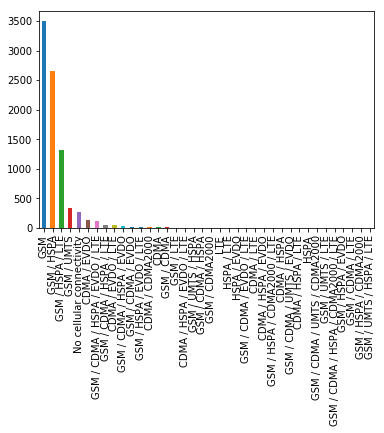

In [12]:
df['network_technology'].value_counts().plot(kind='bar')

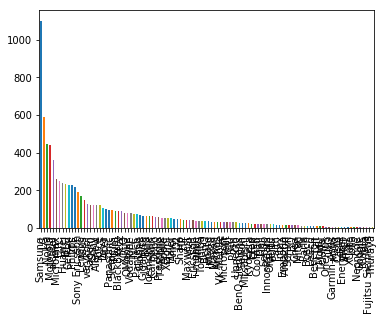

In [13]:
figsize=100
df['brand'].value_counts().plot(kind='bar')

Top ten brand along with there share in percentage:


Samsung     12.783959
LG           6.838201
Nokia        5.169217
Motorola     5.134446
alcatel      4.172462
Micromax     3.025035
HTC          2.885953
Huawei       2.781641
BLU          2.712100
Celkon       2.654149
Name: brand, dtype: float64

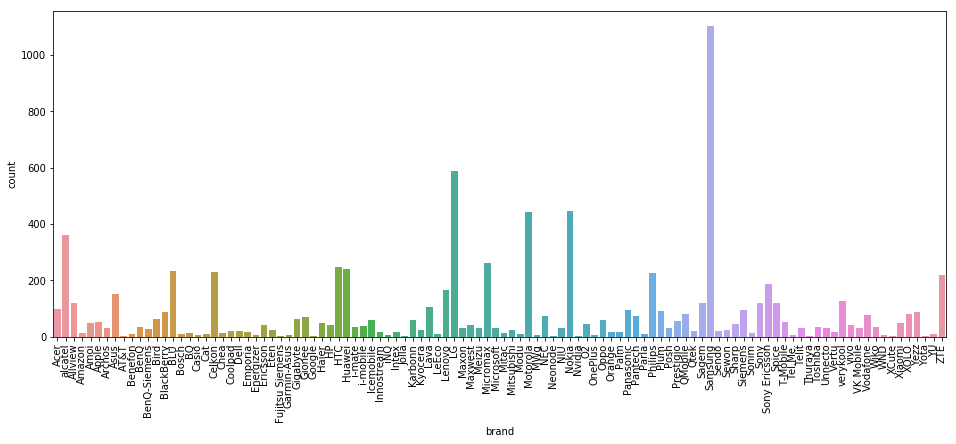

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 6))
chart=sns.countplot(x="brand", data=df)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
print("Top ten brand along with there share in percentage:")
(df["brand"].value_counts().head(10)/df["brand"].shape[0])*100


- There are 108 different brands taken into consideration
- Samsung is the top brand followed by LG
- More than 60 brands have less than 50 instances

#### 2. Check distribution of 'approx_price_EUR' column. Check the presence of invalid values and impute it

In [15]:
df['approx_price_EUR'].value_counts().tail(50)

900      4
570      3
850      3
620      3
690      3
650      3
560      3
580      2
660      2
1000     2
770      2
680      2
800      2
510      2
5160     2
760      2
720      2
730      2
710      2
9000     2
840      1
5900     1
2800     1
880      1
11000    1
1400     1
1150     1
670      1
5020     1
1200     1
13000    1
3320     1
7900     1
2330     1
5000     1
5440     1
11500    1
830      1
27000    1
1470     1
5530     1
8290     1
1070     1
1450     1
6099     1
630      1
5400     1
Black    1
6140     1
1500     1
Name: approx_price_EUR, dtype: int64

In [16]:
 ##Here, we can see that there is a row which has 'Black' as a row. But this is price column it is supposed to have all numerical columns. Instead of imputing it, as it has only one entity, we can remove it safely.

In [17]:
df['approx_price_EUR'].value_counts()

70       302
100      278
80       264
120      246
150      241
90       240
110      218
130      214
60       183
50       179
200      153
180      146
140      143
40       142
30       139
170      134
160      132
250      113
230      110
20       103
190      101
220      101
210       88
300       86
280       70
270       69
260       67
240       62
290       54
350       54
        ... 
840        1
5900       1
2800       1
880        1
11000      1
1400       1
1150       1
670        1
5020       1
1200       1
13000      1
3320       1
7900       1
2330       1
5000       1
5440       1
11500      1
830        1
27000      1
1470       1
5530       1
8290       1
1070       1
1450       1
6099       1
630        1
5400       1
Black      1
6140       1
1500       1
Name: approx_price_EUR, Length: 110, dtype: int64

In [18]:
df.mean()

Series([], dtype: float64)

In [19]:
print("All invalid values in approx_price_EUR including Nan")
invPrice=set()
for price in df["approx_price_EUR"]:
    try:
        int(price)
    except:
        invPrice.add(price)
print(invPrice)


All invalid values in approx_price_EUR including Nan
{nan, 'Black'}


In [20]:
#df[df["approx_price_EUR"].str.isdigit()==False]
#df["approx_price_EUR"].replace("Black", np.nan,inplace=True)
#df["approx_price_EUR"]=df["approx_price_EUR"].astype('float64')


In [21]:
df_new= df[df['approx_price_EUR'] != 'Black']

In [22]:
df_new.shape

(8627, 40)

In [23]:
df_new['approx_price_EUR'].value_counts().sample(10)


400      30
8290      1
11000     1
700      10
5900      1
570       3
280      70
590       5
10       14
210      88
Name: approx_price_EUR, dtype: int64

In [24]:
df_new['approx_price_EUR'] =df_new['approx_price_EUR'].astype('float64')
df_new['approx_price_EUR'].dtypes

dtype('float64')

### 3. Data Cleansing

#### Select instances having brand as 'Samsung' and report the final shape of the dataset

In [25]:
df_samsung=df_new[df_new['brand']== 'Samsung']
df_samsung.shape

(1103, 40)

#### Check for missing values and drop the columns having more than 30% os missing values. And impute the remaining columns with their mode value

In [26]:
x=df_samsung.isnull().sum()/len(df_samsung) > 0.3

In [27]:
cols_to_be_dropped=df_samsung.columns[x]

cols_to_be_dropped

Index(['3G_bands', '4G_bands', 'network_speed', 'OS', 'CPU', 'Chipset', 'GPU',
       'RAM', 'NFC', 'sensors'],
      dtype='object')

In [28]:
df_samsung_new = df_samsung.drop(cols_to_be_dropped, axis=1)

In [29]:
df_samsung_new.shape

(1103, 30)

In [30]:
df_samsung_new.isnull().sum()

brand                   0
model                   0
network_technology      0
2G_bands                0
GPRS                    2
EDGE                    2
announced               0
status                  0
dimentions              2
weight_g               48
weight_oz              48
SIM                     0
display_type            0
display_resolution    133
display_size            0
memory_card             0
internal_memory       176
primary_camera        144
secondary_camera      146
loud_speaker            0
audio_jack              2
WLAN                    1
bluetooth               3
GPS                     0
radio                  14
USB                    85
battery                 0
colors                 49
approx_price_EUR      233
img_url                 0
dtype: int64

In [31]:
new= df_samsung_new.copy()

In [32]:
df_samsung_new= df_samsung_new[~df_samsung_new['approx_price_EUR'].isnull()]

In [33]:
df_samsung_new.shape

(870, 30)

In [34]:
new.shape

(1103, 30)

In [35]:
for i in df_samsung_new.columns:
    if df_samsung_new[i].isnull().any():
        df_samsung_new[i] = df_samsung_new[i].fillna(df_samsung_new[i].mode()[0])


In [36]:
df_samsung_new.shape

(870, 30)

#### Report the final shape of the dataset

In [37]:
df_samsung_new.shape

(870, 30)

In [38]:
df_samsung_new.columns


Index(['brand', 'model', 'network_technology', '2G_bands', 'GPRS', 'EDGE',
       'announced', 'status', 'dimentions', 'weight_g', 'weight_oz', 'SIM',
       'display_type', 'display_resolution', 'display_size', 'memory_card',
       'internal_memory', 'primary_camera', 'secondary_camera', 'loud_speaker',
       'audio_jack', 'WLAN', 'bluetooth', 'GPS', 'radio', 'USB', 'battery',
       'colors', 'approx_price_EUR', 'img_url'],
      dtype='object')

In [39]:
## Model has unique values.So we can drop that column
## img_url is also not needed as it doesnt have any impact on our model

#### Let's select a few important columns for model building. We will encode 'network_technology', 'GPS', 'USB', 'primary_camera', 'display_resolution', 'internal_memory' and use 'approx_price_EUR' as target columns.

We will do the following encoding and check final frequency counts

In [40]:
df_final= df_samsung_new[['network_technology', 'GPS', 'USB', 'primary_camera', 'display_resolution', 'internal_memory', 'approx_price_EUR' ]]

In [41]:
df_final.shape

(870, 7)

#### Encode 'GPS', 'USB' column into two categories (whether GPS/USB is YES or NO)

In [42]:
df_final['USB'].value_counts()

microUSB 2.0                                                393
2                                                           185
Yes                                                          67
No                                                           43
microUSB 2.0 (MHL TV-out)/ USB Host                          32
microUSB 2.0/ USB Host                                       23
1.1                                                          20
microUSB 2.0/ USB On-The-Go                                  19
microUSB                                                     10
microUSB 2.0 (MHL 2 TV-out)/ USB Host                         9
microUSB 2.0 (MHL TV-out)                                     9
microUSB 3.0 (MHL 2.1 TV-out)/ USB Host                       7
2.0/ USB Host                                                 6
2.0/ Type-C 1.0 reversible connector                          4
microUSB 2.0 (MHL 3 TV-out)/ USB Host                         4
3.1/ Type-C 1.0 reversible connector    

In [43]:
df_final['GPS'].value_counts()

No                                                369
Yes with A-GPS                                    203
Yes with A-GPS GLONASS                            166
Yes with A-GPS GLONASS BDS                         38
Yes                                                22
Yes with GLONASS                                   13
A-GPS only; AT&T Navigator                          7
Yes with A-GPS GLONASS/ BDS (market dependant)      7
Yes with A-GPS GLONASS/ BDS (region dependent)      6
Yes with A-GPS GLONASS BDS GALILEO                  4
Yes with A-GPS Samsung Mobile Navigator             4
A-GPS only; Google Maps                             3
A-GPS only; VZ Navigator                            3
Yes GLONASS                                         2
Yes GLONASS BDS                                     2
Yes with S-GPS; GLONASS                             2
Yes with A-GPS; MetroNavigator GPS                  2
Yes; GLONASS                                        2
Yes with A-GPS Bing map     

In [44]:
for i in range(len(df_final['GPS'])):
    if df_final['GPS'].iloc[i] == 'No':
        df_final['GPS'].iloc[i] = 0
    else:
        df_final['GPS'].iloc[i] = 1


In [45]:
df_final['GPS'].value_counts()

1    501
0    369
Name: GPS, dtype: int64

In [46]:
for i in range(len(df_final['USB'])):
    if df_final['USB'].iloc[i] == 'No':
        df_final['USB'].iloc[i] = 0
    else:
        df_final['USB'].iloc[i] = 1

In [47]:
df_final['USB'].value_counts()

1    827
0     43
Name: USB, dtype: int64

#### Encode "network_technology". Create two categories one having value as "No cellular connectivity " and another having all otrher types of connectivity

In [48]:
df_final['network_technology'].value_counts()

GSM / HSPA                        277
GSM                               265
GSM / HSPA / LTE                  155
CDMA / EVDO                        43
No cellular connectivity           36
GSM / UMTS                         28
GSM / CDMA / HSPA / EVDO / LTE     16
CDMA / EVDO / LTE                  15
CDMA / CDMA2000                    10
CDMA                                8
GSM / CDMA / EVDO                   4
GSM / CDMA / HSPA / LTE             3
GSM / CDMA                          3
HSPA / LTE                          2
CDMA / HSPA / EVDO                  1
GSM / CDMA / UMTS / EVDO            1
CDMA / HSPA / EVDO / LTE            1
GSM / UMTS / HSPA / LTE             1
HSPA                                1
Name: network_technology, dtype: int64

In [49]:
for i in range(len(df_final['network_technology'])):
    if df_final['network_technology'].iloc[i] == 'No cellular connectivity':
        df_final['network_technology'].iloc[i] = 0
    else:
        df_final['network_technology'].iloc[i] = 1

In [50]:
df_final['network_technology'].value_counts()

1    834
0     36
Name: network_technology, dtype: int64

#### Encode "display_resolution". Find the resolution number using regex

Encode "display_resolution". Find the resolution number using regex
A RegEx, or Regular Expression, is a sequence of characters that forms a search pattern.

RegEx can be used to check if a string contains the specified search pattern.

findall: Returns a list containing all matches
search: Returns a Match object if there is a match anywhere in the string
split: Returns a list where the string has been split at each match
sub: Replaces one or many matches with a string
Returns a match where the string contains digits (numbers from 0-9) "\d"


In [51]:
text= '2.2 inches (~27.1% screen-to-body ratio)'

In [52]:
import re
re.findall("\d+\.\d", text)

['2.2', '27.1']

In [53]:
X=df_final.copy()


In [54]:
import re
for i in range(len(X['display_resolution'])):
    txt=X['display_resolution'].iloc[i]
    x = re.findall("\d+\.*\d*", txt)
    X['display_resolution'].iloc[i]=x[0]

In [55]:
df_final['display_resolution'].value_counts()

4.0 inches (~59.4% screen-to-body ratio)                21
4.0 inches (~58.3% screen-to-body ratio)                 7
4.0 inches (~59.6% screen-to-body ratio)                 6
5.1 inches (~69.6% screen-to-body ratio)                 6
4.0 inches (~58.0% screen-to-body ratio)                 5
12.2 inches (~71.6% screen-to-body ratio)                5
10.1 inches (~68.9% screen-to-body ratio)                4
4.8 inches (~65.9% screen-to-body ratio)                 4
5.5 inches (~73.3% screen-to-body ratio)                 4
5.0 inches (~72.3% screen-to-body ratio)                 4
7.0 inches (~58.2% screen-to-body ratio)                 4
7.0 inches (~60.2% screen-to-body ratio)                 4
8.9 inches (~63.0% screen-to-body ratio)                 4
4.3 inches (~63.5% screen-to-body ratio)                 4
7.0 inches (~61.3% screen-to-body ratio)                 4
3.5 inches (~52.3% screen-to-body ratio)                 3
3.2 inches (~48.4% screen-to-body ratio)                

In [56]:
X['display_resolution'].value_counts()

4.0     73
2.2     63
2.0     58
2.4     46
3.2     36
2.8     34
5.0     34
3.5     29
3.0     29
2.1     25
2.6     23
7.0     22
10.1    22
5.7     20
1.9     20
1.8     20
1.52    20
5.5     19
5.1     19
4.5     19
4.3     18
1.77    16
3.7     15
2.3     12
8.0     11
4.8     11
1.63     9
4.65     8
4.7      8
3.14     7
        ..
7.7      3
2.62     2
10.5     2
1.85     2
5.8      2
2.66     2
2.5      2
1.67     2
3.27     2
1.7      2
5.25     2
2.26     1
5.01     1
3.97     1
6.2      1
3.4      1
4.2      1
1.78     1
4.66     1
4.77     1
18.4     1
1.93     1
1.38     1
1.92     1
2.9      1
9.6      1
5.6      1
6.3      1
3.35     1
1.4      1
Name: display_resolution, Length: 79, dtype: int64

#### Encode "internal_memory". Create two categories having values in MB, or GB using regex

Hint - 
mb = re.search('MB',txt)
    if mb:
        X['internal_memory'].iloc[i]=1
    else:
        X['internal_memory'].iloc[i]=0

In [57]:
X['internal_memory'].head()

5962    32 GB
5963    64 GB
5964    16 GB
5965    16 GB
5966    16 GB
Name: internal_memory, dtype: object

In [58]:
for i in range(len(X['internal_memory'])):
    txt= str(X['internal_memory'].iloc[i])
    
    x=re.search('GB', txt)
    if x:
        X['internal_memory'].iloc[i]=1
    else:
        X['internal_memory'].iloc[i]=0

In [59]:
X['internal_memory'].value_counts()

1    477
0    393
Name: internal_memory, dtype: int64

#### Encode "primary_camera". Create 2-3 categories having no camera, camera in M, or VGA using regex

In [60]:
X['primary_camera'].nunique()

104

In [64]:
for i in range(len(X['primary_camera'])):
    txt= str(X['primary_camera'].iloc[i])
    
    x1=re.search('MP', txt)
    x2=re.search('VGA', txt)
    if x1:
        X['primary_camera'].iloc[i]=1
    elif x2:
        X['primary_camera'].iloc[i]=2
    else:
        X['primary_camera'].iloc[i]=0 

In [65]:
X['primary_camera'].value_counts()

0    870
Name: primary_camera, dtype: int64

In [66]:
X['primary_camera'].head(10)

5962    0
5963    0
5964    0
5965    0
5966    0
5968    0
5969    0
5972    0
5973    0
5974    0
Name: primary_camera, dtype: int64

### 4. Data Preparation

Segregate X and y

In [67]:
X.head(2)

,network_technology,GPS,USB,primary_camera,display_resolution,internal_memory,approx_price_EUR
5962,1,1,1,0,5.7,1,250.0
5963,1,1,1,0,5.5,1,300.0


In [68]:
y=X['approx_price_EUR']

In [69]:
X=X.drop(['approx_price_EUR'], axis =1)

### 5. EDA

#### Perform univariate analysis by checking frequency distribution of all the features

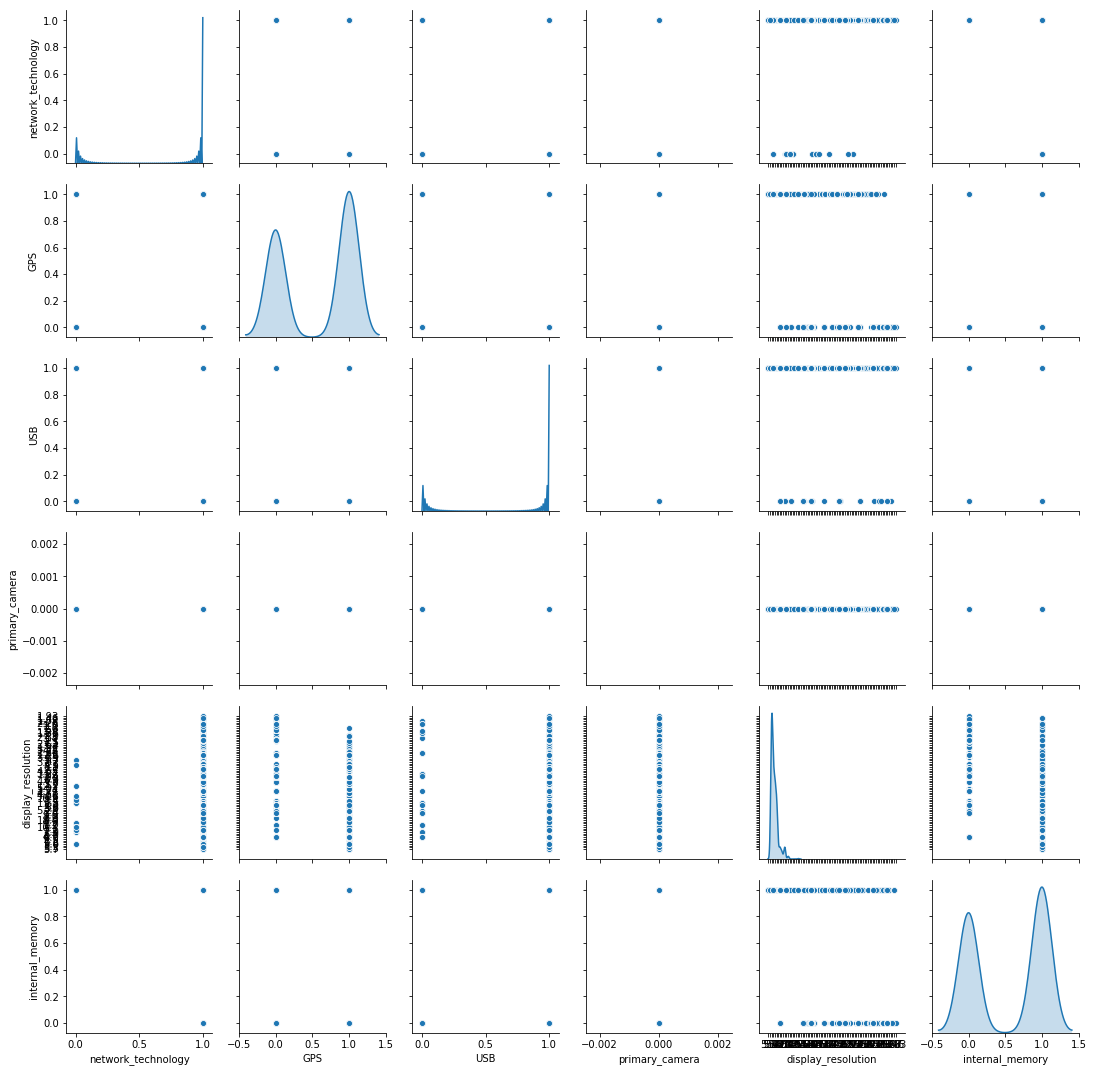

In [72]:
sns.pairplot(X, diag_kind="kde")

#### Perform bivariate analysis by checking doing crosstab between independent and dependent features

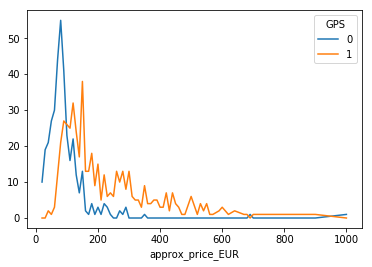

In [72]:
pd.crosstab(y,X['GPS']).plot()

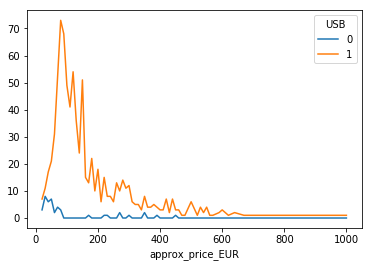

In [73]:
pd.crosstab(y,X['USB']).plot()

### 6. Split data into Train and Test set and build a Supervised Learning model using Linear Regression

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [77]:

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [78]:
regression_model.score(X_train, y_train)

0.4442437002333147

In [79]:
regression_model.score(X_test, y_test)

0.4269625963379747

### 7. Train a KNN model and check its performance

In [80]:
from sklearn.neighbors import KNeighborsRegressor


In [81]:
knn = KNeighborsRegressor(n_neighbors=9)
knn.fit(X_train,y_train)
knn.score(X_train,y_train)


0.6759372185965588

In [82]:
knn.score(X_test,y_test)


0.7245742841143317

In [ ]:
# Here we can see that the scores are very less. As we have considered only 5-6 features, the scores are less. This requires further more analysis to improve the model and the scores

### 8. Further Explore 

1. Impute the remaining features and check the accuracy
2. Use brand as a feature and predict price

                                     End of case study